In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel("../df/moscow_only.xlsx")
df = df.dropna(subset=["Цена"])
df = df[df["Город"] == "Москва"].copy()
df.head()

,Название,Цена,Дата,Телефон,Оператор,Контактное лицо (автор объявления),Тип автора,Регион,Город,Метро/Район,...,Источник,lat,lng,Персона для контактов,Доп.параметры,URL,Ссылки на картинки,Регион мобильного телефона,Номер подменён,"Расстояние до метро, км"
0,"Склад в Москва Кавказский бул., 57 (1961 м²)",3525282,2025-12-23 04:22:42,89153057180,Мобильные ТелеСистемы,PERFECT,Агентство,Москва,Москва,Кантемировская,...,cian.ru,55.628835,37.633679,NaN,Этаж=-1|Этажность здания=1|Тип объявления=Сдам...,https://www.cian.ru/rent/commercial/325173412,https://images.cdn-cian.ru/images/2741869710-1...,г. Москва и Московская область,да,4.583
1,"Офис в Москва Новодмитровская ул., 2к1 (145 м²)",549000,2025-12-23 04:22:42,89853357183,Мобильные ТелеСистемы,ID56470,Агентство,Москва,Москва,Дмитровская,...,cian.ru,55.804936,37.589922,NaN,Этаж=10|Этажность здания=22|Тип объявления=Сда...,https://www.cian.ru/rent/commercial/325046250,https://images.cdn-cian.ru/images/ofis-moskva-...,г. Москва и Московская область,да,0.75
2,"Офис в Москва Новодмитровская ул., 2к1 (145 м²)",549000,2025-12-23 04:22:42,89853357183,Мобильные ТелеСистемы,ID56470,Агентство,Москва,Москва,Дмитровская,...,cian.ru,55.804936,37.589922,NaN,Этаж=10|Этажность здания=22|Тип объявления=Сда...,https://www.cian.ru/rent/commercial/325046146,https://images.cdn-cian.ru/images/ofis-moskva-...,г. Москва и Московская область,да,0.75
3,"Офис в Москва ул. Большая Дмитровка, 13 (118 м²)",539850,2025-12-23 04:22:42,89169358632,Мобильные ТелеСистемы,Агент Jcat Недвижимость (Jcat Недвижимость),Агентство,Москва,Москва,Театральная,...,cian.ru,55.762358,37.613269,NaN,Этаж=4|Этажность здания=4|Тип объявления=Сдам|...,https://www.cian.ru/rent/commercial/325038594,https://images.cdn-cian.ru/images/2737685052-1...,г. Москва и Московская область,да,0.667
4,"Офис в Москва ул. Гиляровского, 65С1 (751 м²)",1689750,2025-12-23 04:22:42,89855041630,Мобильные ТелеСистемы,Олег Макеев (Альфа-Риэлт),Агентство,Москва,Москва,Рижская,...,cian.ru,55.789294,37.632745,NaN,Этаж=5|Этажность здания=5|Тип объявления=Сдам|...,https://www.cian.ru/rent/commercial/325091858,https://images.cdn-cian.ru/images/2739269014-1...,г. Москва и Московская область,да,0.583


# Первичная обработка данных

In [2]:
df.shape

(108954, 26)

In [3]:
df.isna().sum()

Название                                   0
Цена                                       0
Дата                                       0
Телефон                                    0
Оператор                                   0
Контактное лицо (автор объявления)       451
Тип автора                                 0
Регион                                     0
Город                                      0
Метро/Район                               12
Адрес                                     17
Описание                                1095
Тип объявления                             0
Категория1                                 0
Категория2                                 0
ID на сайте                                0
Источник                                   0
lat                                        1
lng                                        1
Персона для контактов                 108954
Доп.параметры                              0
URL                                        0
Ссылки на 

In [4]:
df.nunique()

Название                               52386
Цена                                   27451
Дата                                   47814
Телефон                                11380
Оператор                                   6
Контактное лицо (автор объявления)      6339
Тип автора                                 3
Регион                                     2
Город                                      1
Метро/Район                              383
Адрес                                  17898
Описание                               91260
Тип объявления                             1
Категория1                                 1
Категория2                                 1
ID на сайте                           108954
Источник                                   3
lat                                    16095
lng                                    15717
Персона для контактов                      0
Доп.параметры                          46910
URL                                   108954
Ссылки на 

In [5]:
df = df.drop([
    'Телефон', 'Оператор', 'Контактное лицо (автор объявления)', 'Персона для контактов',
    'Номер подменён', 'Регион мобильного телефона', 'Регион', 'Город', 'Описание',
    'Тип объявления', 'Категория1', 'Категория2', 'Тип объявления',
], axis=1)

In [6]:
df.columns

Index(['Название', 'Цена', 'Дата', 'Тип автора', 'Метро/Район', 'Адрес',
       'ID на сайте', 'Источник', 'lat', 'lng', 'Доп.параметры', 'URL',
       'Ссылки на картинки', 'Расстояние до метро, км'],
      dtype='object')

In [7]:
df = df.set_index(['ID на сайте', 'Источник'])

In [8]:
df["Доп.параметры"].iloc[10]

'Этаж=65|Этажность здания=95|Тип объявления=Сдам|Вид объекта=Офисное помещение|Общая площадь=74'

In [9]:
def parse_parameters(v):
    return dict(
        pair.split("=")
        for pair in v.split("|")
    )

parse_parameters(df["Доп.параметры"].iloc[10])

{'Этаж': '65',
 'Этажность здания': '95',
 'Тип объявления': 'Сдам',
 'Вид объекта': 'Офисное помещение',
 'Общая площадь': '74'}

In [10]:
_ = df["Доп.параметры"].apply(parse_parameters)
params_parsed = pd.json_normalize(_)
params_parsed.index = df.index
params_parsed

,,Этаж,Этажность здания,Тип объявления,Вид объекта,Общая площадь,Ед. измерения площади,Категория,Класс здания
ID на сайте,Источник,,,,,,,,
325173412,cian.ru,-1,1,Сдам,Складское помещение,1961,NaN,NaN,NaN
325046250,cian.ru,10,22,Сдам,Офисное помещение,145,NaN,NaN,NaN
325046146,cian.ru,10,22,Сдам,Офисное помещение,145,NaN,NaN,NaN
325038594,cian.ru,4,4,Сдам,Офисное помещение,118,NaN,NaN,NaN
325091858,cian.ru,5,5,Сдам,Офисное помещение,751,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
7554570352,avito.ru,1,NaN,Сдам,NaN,50,NaN,NaN,NaN
7546763783,avito.ru,2,NaN,Сдам,Офисное помещение,211,NaN,NaN,NaN
7546885417,avito.ru,2,NaN,Сдам,Помещение свободного назначения,560,NaN,NaN,NaN


In [11]:
params_parsed.isna().sum() / params_parsed.shape[0] * 100

Этаж                      1.543771
Этажность здания          2.141271
Тип объявления            0.000000
Вид объекта               0.040384
Общая площадь             0.000000
Ед. измерения площади    99.858656
Категория                99.921068
Класс здания             99.407089
dtype: float64

In [12]:
params_parsed.nunique()

Этаж                       99
Этажность здания           98
Тип объявления              1
Вид объекта                 8
Общая площадь            5019
Ед. измерения площади       2
Категория                   3
Класс здания                4
dtype: int64

In [13]:
params_parsed["Ед. измерения площади"].unique()

array([nan, 'сот.', 'га.'], dtype=object)

In [14]:
params_parsed = params_parsed.drop(["Класс здания", "Тип объявления"], axis=1)

In [15]:
df = pd.concat(
    [
        df.drop("Доп.параметры", axis=1),
        params_parsed
    ],
    axis=1
)

,,Название,Цена,Дата,Тип автора,Метро/Район,Адрес,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь,Ед. измерения площади,Категория
ID на сайте,Источник,,,,,,,,,,,,,,,,,
325173412,cian.ru,"Склад в Москва Кавказский бул., 57 (1961 м²)",3525282,2025-12-23 04:22:42,Агентство,Кантемировская,"Кавказский бул., 57",55.628835,37.633679,https://www.cian.ru/rent/commercial/325173412,https://images.cdn-cian.ru/images/2741869710-1...,4.583,-1,1,Складское помещение,1961,NaN,NaN
325046250,cian.ru,"Офис в Москва Новодмитровская ул., 2к1 (145 м²)",549000,2025-12-23 04:22:42,Агентство,Дмитровская,"Новодмитровская ул., 2к1",55.804936,37.589922,https://www.cian.ru/rent/commercial/325046250,https://images.cdn-cian.ru/images/ofis-moskva-...,0.75,10,22,Офисное помещение,145,NaN,NaN
325046146,cian.ru,"Офис в Москва Новодмитровская ул., 2к1 (145 м²)",549000,2025-12-23 04:22:42,Агентство,Дмитровская,"Новодмитровская ул., 2к1",55.804936,37.589922,https://www.cian.ru/rent/commercial/325046146,https://images.cdn-cian.ru/images/ofis-moskva-...,0.75,10,22,Офисное помещение,145,NaN,NaN
325038594,cian.ru,"Офис в Москва ул. Большая Дмитровка, 13 (118 м²)",539850,2025-12-23 04:22:42,Агентство,Театральная,"ул. Большая Дмитровка, 13",55.762358,37.613269,https://www.cian.ru/rent/commercial/325038594,https://images.cdn-cian.ru/images/2737685052-1...,0.667,4,4,Офисное помещение,118,NaN,NaN
325091858,cian.ru,"Офис в Москва ул. Гиляровского, 65С1 (751 м²)",1689750,2025-12-23 04:22:42,Агентство,Рижская,"ул. Гиляровского, 65С1",55.789294,37.632745,https://www.cian.ru/rent/commercial/325091858,https://images.cdn-cian.ru/images/2739269014-1...,0.583,5,5,Офисное помещение,751,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7554570352,avito.ru,52 кв.м с пятью окнами на Летниковской,300000,2025-08-01 00:07:50,Частное лицо (фильтр),Павелецкая,"Летниковская ул., 10с2",55.725586,37.643192,https://www.avito.ru/moskva/kommercheskaya_ned...,https://60.img.avito.st/image/1/1.Cs5EN7a5pidy...,неизвестно,1,NaN,NaN,50,NaN,NaN
7546763783,avito.ru,Аренда офиса в центре Москвы,1434052,2025-08-01 00:07:25,Агентство,Библиотека им. Ленина,"Романов пер., 4с2",55.754568,37.609586,https://www.avito.ru/moskva/kommercheskaya_ned...,https://60.img.avito.st/image/1/1.LNcb27a5gD4t...,неизвестно,2,NaN,Офисное помещение,211,NaN,NaN
7546885417,avito.ru,"560 м², ПСН, трафик",1500000,2025-08-01 00:05:13,Агентство,Новослободская,"Новослободская ул., 3",55.779155,37.600594,https://www.avito.ru/moskva/kommercheskaya_ned...,https://20.img.avito.st/image/1/1.oJ1hcra5DHRX...,неизвестно,2,NaN,Помещение свободного назначения,560,NaN,NaN


In [18]:
df["Дата"] = pd.to_datetime(df["Дата"])

ID на сайте  Источник
325173412    cian.ru    2025-12-23 04:22:42
325046250    cian.ru    2025-12-23 04:22:42
325046146    cian.ru    2025-12-23 04:22:42
325038594    cian.ru    2025-12-23 04:22:42
325091858    cian.ru    2025-12-23 04:22:42
                                ...        
7554570352   avito.ru   2025-08-01 00:07:50
7546763783   avito.ru   2025-08-01 00:07:25
7546885417   avito.ru   2025-08-01 00:05:13
7526832954   avito.ru   2025-08-01 00:04:30
7554650282   avito.ru   2025-08-01 00:00:00
Name: Дата, Length: 108954, dtype: datetime64[ns]

In [22]:
df["Расстояние до метро, км"] = df["Расстояние до метро, км"].replace({"неизвестно": np.nan}).values

C:\Users\Oleg\AppData\Local\Temp\ipykernel_7360\1761577118.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Расстояние до метро, км"] = data["Расстояние до метро, км"].replace({"неизвестно": np.nan}).values


In [23]:
df[[
    "Расстояние до метро, км",
    "Этаж",
    "Общая площадь",
    "Этажность здания",
]] = df[[
    "Расстояние до метро, км",
    "Этаж",
    "Общая площадь",
    "Этажность здания",
]].astype(float)

In [24]:
df.isna().sum()

Название                        0
Цена                            0
Дата                            0
Тип автора                      0
Метро/Район                    12
Адрес                          17
lat                             1
lng                             1
URL                             0
Ссылки на картинки           2006
Расстояние до метро, км      1592
Этаж                         1682
Этажность здания             2333
Вид объекта                    44
Общая площадь                   0
Ед. измерения площади      108800
Категория                  108868
dtype: int64

In [25]:
df["Ед. измерения площади"].value_counts()

Ед. измерения площади
сот.    148
га.       6
Name: count, dtype: int64

In [26]:
df.dropna(subset=["Общая площадь", "Ед. измерения площади"])[["Общая площадь", "Ед. измерения площади"]]

,,Общая площадь,Ед. измерения площади
ID на сайте,Источник,,
324994461,cian.ru,11.46,сот.
325228766,cian.ru,14.15,сот.
324876901,cian.ru,890.00,сот.
324181286,cian.ru,6.00,сот.
325140435,cian.ru,0.60,сот.
...,...,...,...
319812755,cian.ru,1.00,га.
319812681,cian.ru,100.00,сот.
319916210,cian.ru,180.00,сот.


In [27]:
df[["Общая площадь", "Ед. измерения площади"]].dropna()

,,Общая площадь,Ед. измерения площади
ID на сайте,Источник,,
324994461,cian.ru,11.46,сот.
325228766,cian.ru,14.15,сот.
324876901,cian.ru,890.00,сот.
324181286,cian.ru,6.00,сот.
325140435,cian.ru,0.60,сот.
...,...,...,...
319812755,cian.ru,1.00,га.
319812681,cian.ru,100.00,сот.
319916210,cian.ru,180.00,сот.


In [29]:
df.loc[
    df["Ед. измерения площади"] == "сот.",
    "Общая площадь"
] *= 100

df.loc[
    df["Ед. измерения площади"] == "га.",
    "Общая площадь"
] *= 10000

In [30]:
df = df.drop("Ед. измерения площади", axis=1)

**Метро нужно тоже провалидировать**

In [31]:
sorted(df["Метро/Район"].dropna().unique())

['Авиамоторная',
 'Автозаводская',
 'Академическая',
 'Александровский сад',
 'Алексеевская',
 'Алма-Атинская',
 'Алтуфьево',
 'Аминьевская',
 'Андроновка',
 'Аннино',
 'Апрелевка',
 'Арбатская',
 'Аэропорт',
 'Аэропорт Внуково',
 'Бабушкинская',
 'Багратионовская',
 'Баковка',
 'Балтийская',
 'Баррикадная',
 'Бауманская',
 'Беговая',
 'Белокаменная',
 'Беломорская',
 'Белорусская',
 'Беляево',
 'Бескудниково',
 'Бибирево',
 'Библиотека им. Ленина',
 'Бирюлёво',
 'Битца',
 'Борисово',
 'Боровицкая',
 'Боровское шоссе',
 'Ботанический сад',
 'Братиславская',
 'Бульвар Адмирала Ушакова',
 'Бульвар Генерала Карбышева',
 'Бульвар Дмитрия Донского',
 'Бульвар Рокоссовского',
 'Бульвар адмирала Ушакова',
 'Бунинская Аллея',
 'Бунинская аллея',
 'Бутово',
 'Бутырская',
 'ВАО',
 'ВДНХ',
 'Вавиловская',
 'Варшавская',
 'Ватутинки',
 'Верхние Котлы',
 'Верхние Лихоборы',
 'Верхние котлы',
 'Вешняки',
 'Владыкино',
 'Внуково',
 'Водный Стадион',
 'Водный стадион',
 'Войковская',
 'Волгоградский п

In [32]:
df["Метро/Район"] = df["Метро/Район"].replace({
    'Бунинская аллея': 'Бунинская Аллея',
    'Верхние котлы': 'Верхние Котлы',
    'Водный стадион': 'Водный Стадион',
    'Воробьёвы горы': 'Воробьёвы Горы',
    'Деловой центр': 'Деловой Центр',
    'Зеленоград—Крюково': 'Зеленоград — Крюково',
    'Кленовый бульвар': 'Кленовый Бульвар',
    'Красные ворота': 'Красные Ворота',
    'Крестьянская застава': 'Крестьянская Застава',
    'Кузнецкий мост': 'Кузнецкий Мост',
    'Октябрьское поле': 'Октябрьское Поле',
    'Охотный ряд': 'Охотный Ряд',
    'Парк культуры': 'Парк Культуры',
    'Петровский парк': 'Петровский Парк',
    'Площадь трёх вокзалов': 'Площадь Трёх Вокзалов',
    'Рабочий посёлок': 'Рабочий Посёлок',
    'Речной вокзал': 'Речной Вокзал',
    'Славянский бульвар': 'Славянский Бульвар',
    'Соколиная гора': 'Соколиная Гора',
    'Сретенский бульвар': 'Сретенский Бульвар',
    'Улица 1905 года': 'Улица 1905 Года',
    'Улица академика Янгеля': 'Улица Академика Янгеля',
    'Цветной бульвар': 'Цветной Бульвар',
    'Чистые пруды': 'Чистые Пруды',
})

# Фильтрация и аналитика

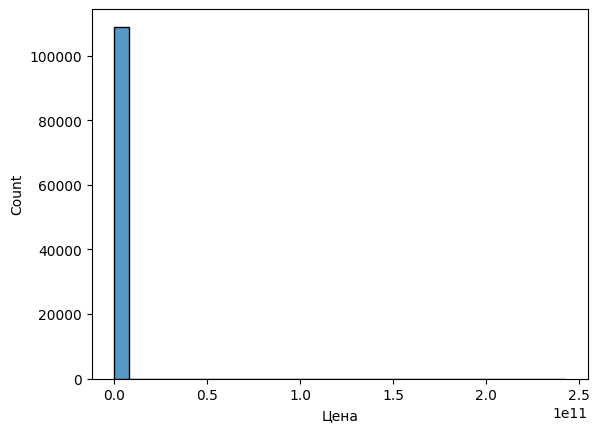

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

df["Цена"] = df["Цена"].astype(float)
df["Цена / м2"] = df["Цена"] / df["Общая площадь"]
df["Log(Цена)"] = np.log1p(df["Цена"])

sns.histplot(df["Цена"], bins=30)
plt.show()

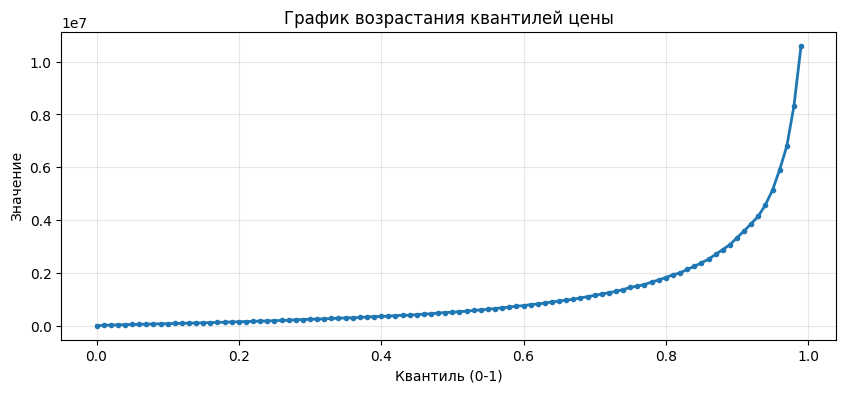

In [34]:
def get_quantplot(series):
    quantiles = np.arange(0, 1.00, 0.01)
    q_values = series.quantile(quantiles)
    
    plt.figure(figsize=(10, 4))
    q_values.plot(kind='line', linewidth=2, marker='o', markersize=3)
    plt.title('График возрастания квантилей цены')
    plt.xlabel('Квантиль (0-1)')
    plt.ylabel('Значение')
    plt.grid(True, alpha=0.3)
    plt.show()

get_quantplot(df["Цена"])

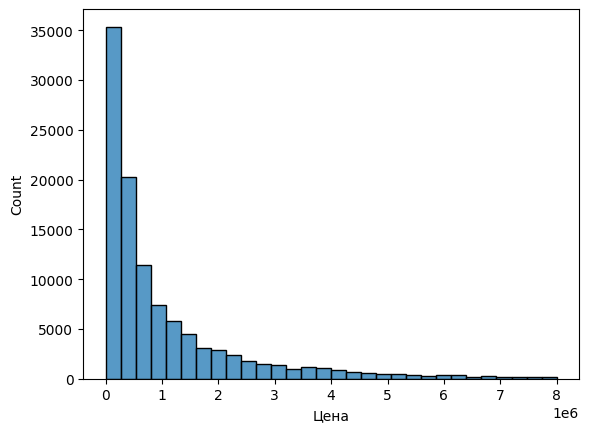

In [35]:
df = df[df["Цена"] <= 8e6].copy()
sns.histplot(df["Цена"], bins=30)
plt.show()

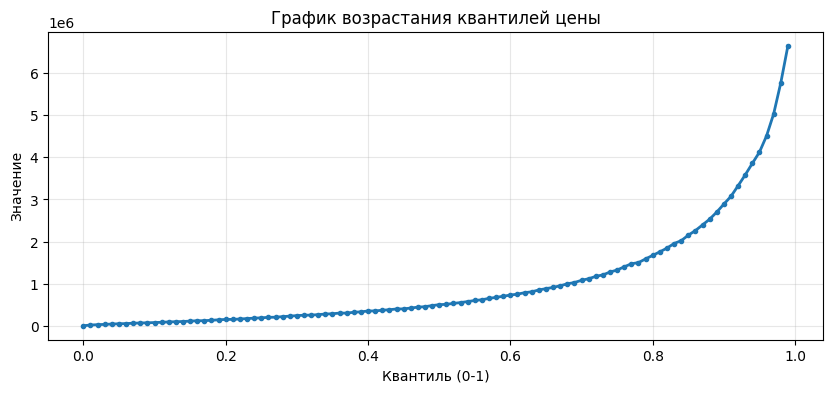

In [36]:
get_quantplot(df["Цена"])

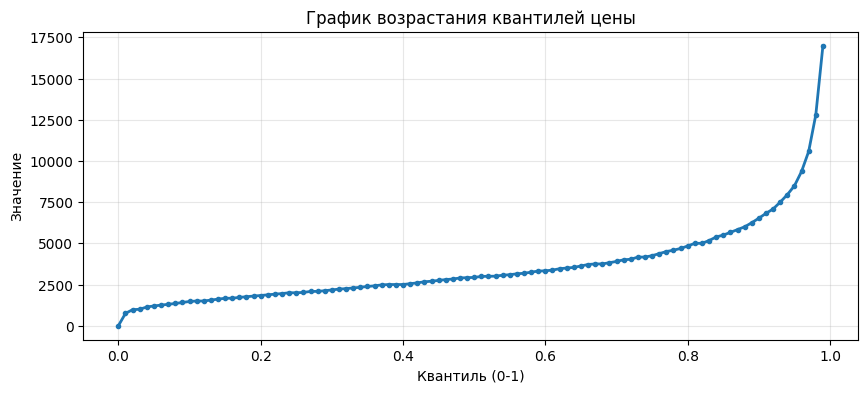

In [37]:
get_quantplot(df["Цена / м2"])

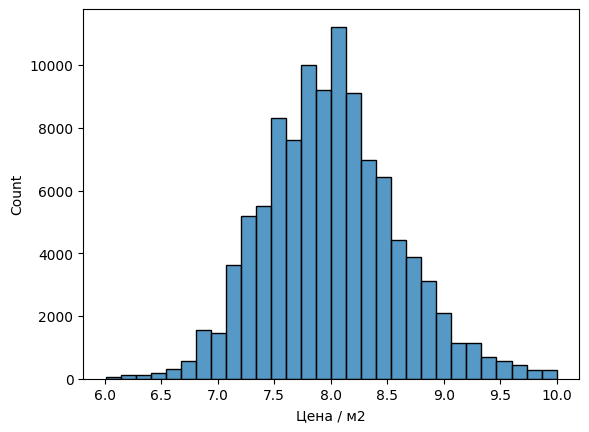

In [38]:
df = df[(np.log1p(df["Цена / м2"]) <= 10) & (np.log1p(df["Цена / м2"]) >= 6)].copy()
sns.histplot(np.log1p(df["Цена / м2"]), bins=30)
plt.show()

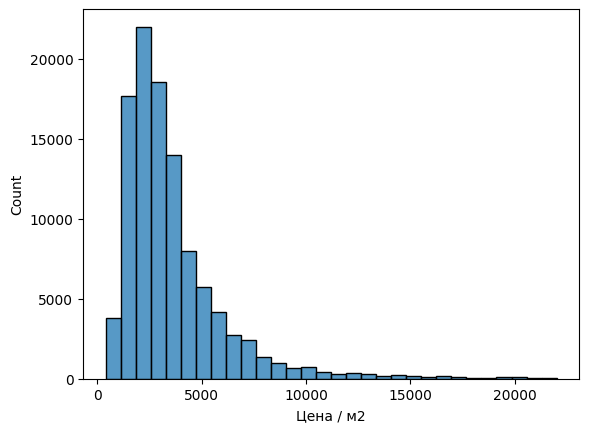

In [39]:
sns.histplot(df["Цена / м2"], bins=30)
plt.show()

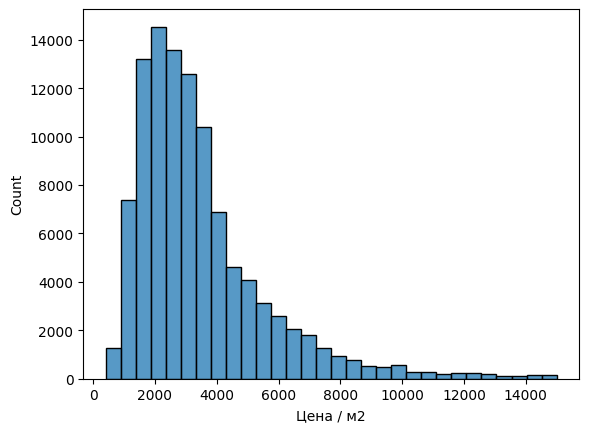

In [40]:
df = df[df["Цена / м2"] <= 15000].copy()
sns.histplot(df["Цена / м2"], bins=30)
plt.show()

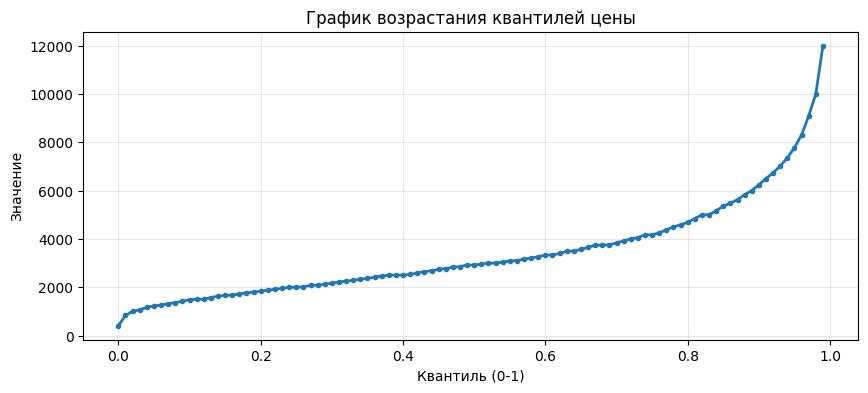

In [41]:
get_quantplot(df["Цена / м2"])

In [42]:
df = df[df["Вид объекта"] != "Коммерческая земля"].copy()
df = df[df["Вид объекта"] != "Производственное помещение"].copy()
df = df[df["Вид объекта"] != "Складское помещение"].copy()
df = df[df["Вид объекта"] != "Гостиница"].copy()
df = df[df['Общая площадь'] <= 5000].copy()
df = df[df['Общая площадь'] >= 20].copy()

df.shape

(92612, 18)

In [43]:
df["Вид объекта"].value_counts()

Вид объекта
Офисное помещение                  60952
Помещение свободного назначения    22310
Торговое помещение                  8191
Здание                              1118
Name: count, dtype: int64

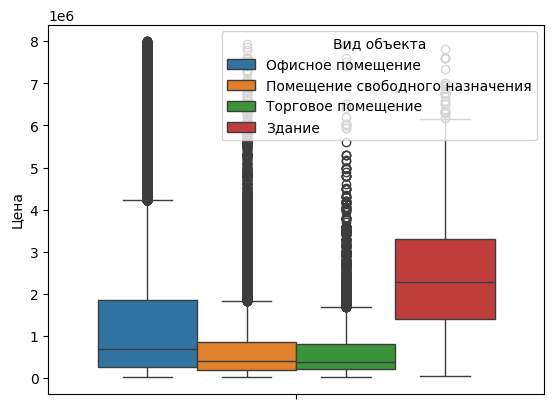

In [44]:
sns.boxplot(df, y="Цена", hue="Вид объекта")
plt.show()

In [45]:
df["Общая площадь"].describe(percentiles=(0.1, 0.25, 0.5, 0.75, 0.9))

count    92612.000000
mean       340.848096
std        385.814506
min         20.000000
10%         40.500000
25%         78.000000
50%        181.000000
75%        458.000000
90%        911.000000
max       1996.000000
Name: Общая площадь, dtype: float64

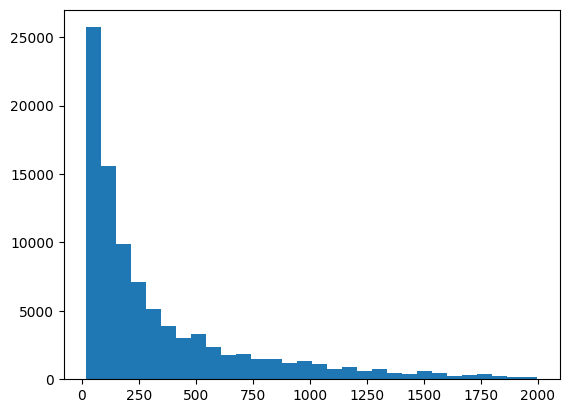

In [46]:
plt.hist(df['Общая площадь'], bins=30)
plt.show()

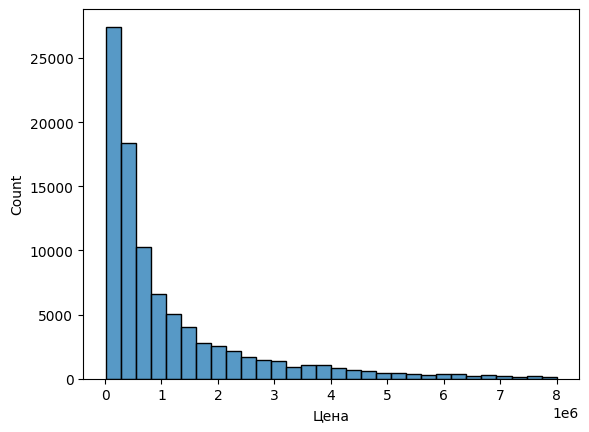

In [47]:
sns.histplot(df["Цена"], bins=30)
plt.show()

In [48]:
df['Цена_bin'] = pd.cut(df['Цена'], bins=10)
df['Цена_bin'].value_counts()

Цена_bin
(4012.0, 810800.0]        56080
(810800.0, 1609600.0]     15760
(1609600.0, 2408400.0]     7540
(2408400.0, 3207200.0]     4461
(3207200.0, 4006000.0]     3104
(4006000.0, 4804800.0]     2113
(4804800.0, 5603600.0]     1264
(5603600.0, 6402400.0]     1071
(6402400.0, 7201200.0]      705
(7201200.0, 8000000.0]      514
Name: count, dtype: int64

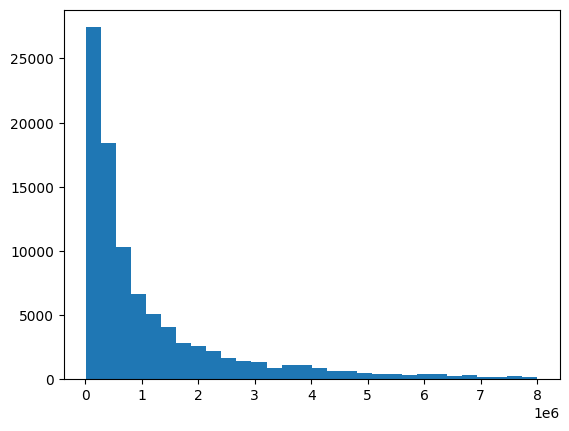

In [49]:
plt.hist(df["Цена"], bins=30)
plt.show()

In [50]:
df["Цена"].describe(percentiles=(0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95)).astype(int)

count      92612
mean     1145033
std      1433398
min        12000
1%         42833
5%         75000
10%       110011
25%       234000
50%       550000
75%      1464870
90%      3097699
95%      4331250
max      8000000
Name: Цена, dtype: int64

In [51]:
df.isna().sum() / df.shape[0]

Название                   0.000000
Цена                       0.000000
Дата                       0.000000
Тип автора                 0.000000
Метро/Район                0.000086
Адрес                      0.000162
lat                        0.000011
lng                        0.000011
URL                        0.000000
Ссылки на картинки         0.018464
Расстояние до метро, км    0.011726
Этаж                       0.014663
Этажность здания           0.017136
Вид объекта                0.000443
Общая площадь              0.000000
Категория                  1.000000
Цена / м2                  0.000000
Log(Цена)                  0.000000
Цена_bin                   0.000000
dtype: float64

In [52]:
df = df.drop(["Категория", "Цена_bin", "Log(Цена)"], axis=1)

In [53]:
df["Тип автора"] = df["Тип автора"].replace({
    "Частное лицо (фильтр)": "Частное лицо",
})

In [54]:
df["Вид объекта"] = df["Вид объекта"].replace({
    "Торговое помещение": "Торговое / Свободного назначения",
    "Помещение свободного назначения": "Торговое / Свободного назначения",
})

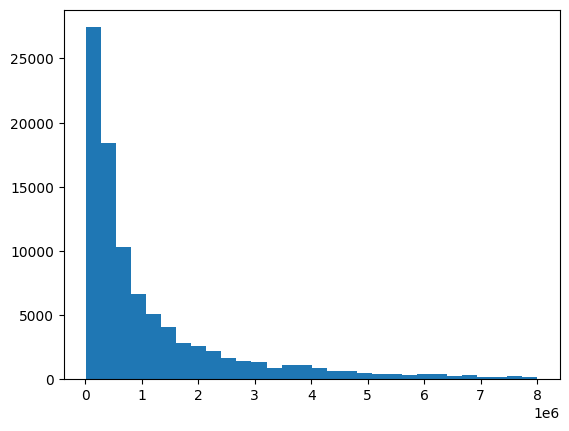

In [55]:
plt.hist(df["Цена"], bins=30)
plt.show()

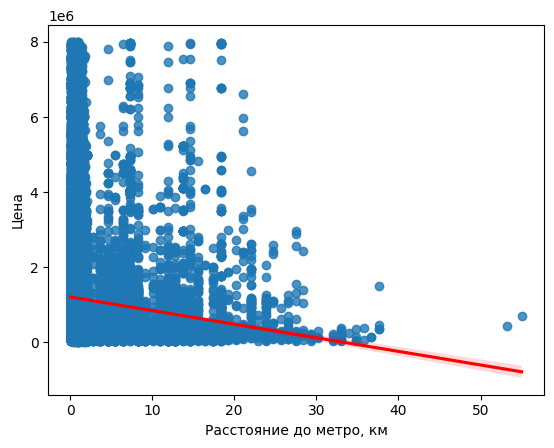

In [56]:
sns.regplot(df, x="Расстояние до метро, км", y="Цена", line_kws={"color": "red"})
plt.show()

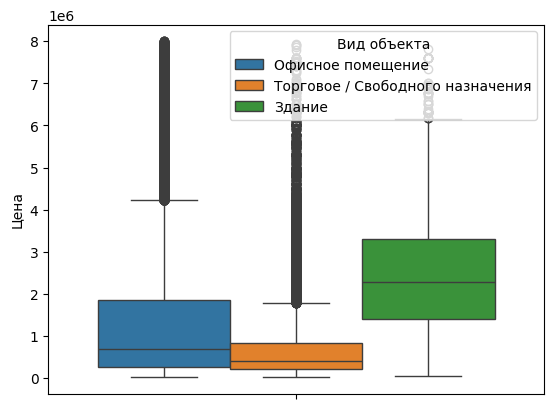

In [57]:
sns.boxplot(df, y="Цена", hue="Вид объекта")
plt.show()

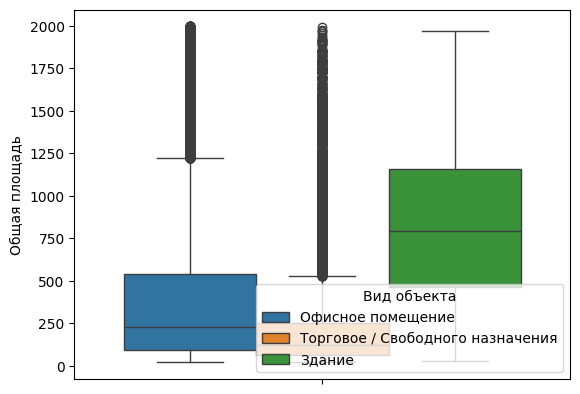

In [58]:
sns.boxplot(df, y="Общая площадь", hue="Вид объекта")
plt.show()

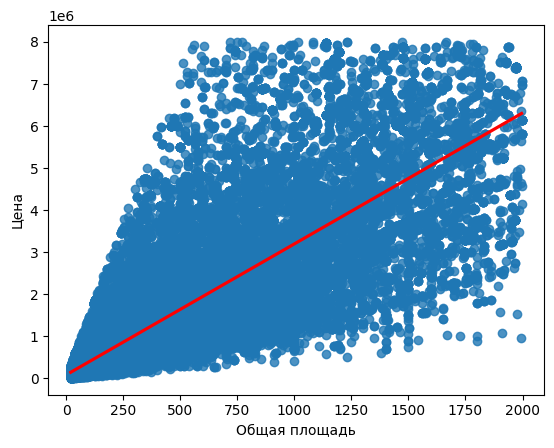

In [59]:
sns.regplot(df, x="Общая площадь", y="Цена", line_kws={"color": "red"})
plt.show()

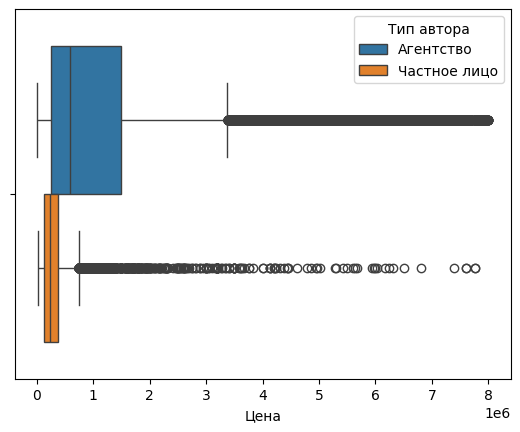

In [60]:
sns.boxplot(df, x="Цена", hue="Тип автора")
plt.show()

In [61]:
df.shape

(92612, 16)

# Обрезка данных (слишком много)

In [62]:
import pandas as pd
import numpy as np

df['price_quantile'] = pd.qcut(df['Цена'], 10, labels=False)
df['area_quantile'] = pd.qcut(df['Общая площадь'], 10, labels=False)
df['distance_quantile'] = pd.qcut(df['Расстояние до метро, км'], 10, labels=False)
df['square_price_quantile'] = pd.qcut(df['Цена / м2'], 10, labels=False)

df_sample = df.groupby(['price_quantile', 'area_quantile', 'distance_quantile', 'square_price_quantile'], 
                   group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))

print(f"Исходно: {len(df):,}, после: {len(df_sample):,}")

Исходно: 92,612, после: 9,070


C:\Users\Oleg\AppData\Local\Temp\ipykernel_7360\4215935051.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))


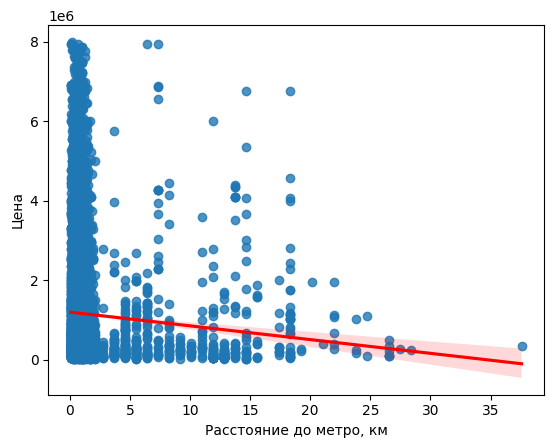

In [63]:
sns.regplot(df_sample, x="Расстояние до метро, км", y="Цена", line_kws={"color": "red"})
plt.show()

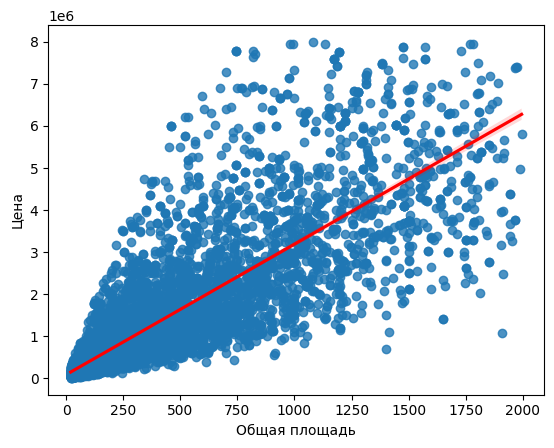

In [64]:
sns.regplot(df_sample, x="Общая площадь", y="Цена", line_kws={"color": "red"})
plt.show()

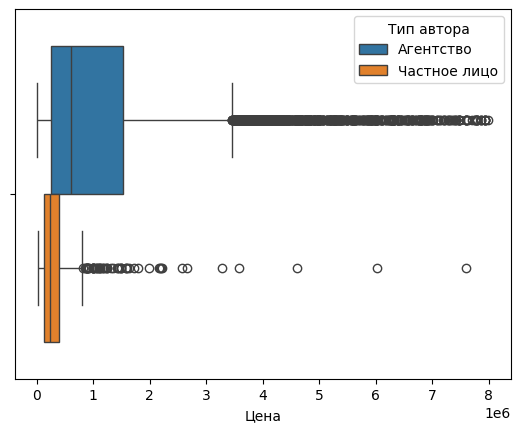

In [65]:
sns.boxplot(df_sample, x="Цена", hue="Тип автора")
plt.show()

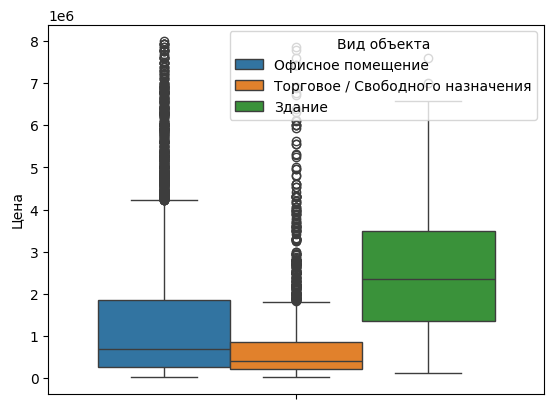

In [66]:
sns.boxplot(df_sample, y="Цена", hue="Вид объекта")
plt.show()

In [67]:
df_sample["Ссылки на картинки"] = df_sample["Ссылки на картинки"].str.split(',')
df_sample = df_sample.drop(['price_quantile', 'area_quantile', 'distance_quantile', 'square_price_quantile', 'Цена / м2'], axis=1)
df_sample.to_excel("../df/moscow_transformed.xlsx")